# Olist 巴西電商資料分析

## 分析目標
以巴西電商平台 Olist 2016–2018 訂單資料，回答：
1. **業績**：營收成長趨勢與主要貢獻品類為何？
2. **體驗**：客戶評分分布與物流效率如何？哪些州表現好/差？
3. **客戶**：以 RFM 分群，找出高價值與高流失風險客戶。

## 工具
SQLite + SQL + pandas + matplotlib + Tableau

## 資料來源
[Olist Brazilian E-Commerce Dataset (Kaggle)](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

## 1. 載入套件與資料庫設定

In [1]:
import os
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Microsoft JhengHei'
matplotlib.rcParams['axes.unicode_minus'] = False

# 路徑設定（相對路徑，方便跨環境執行）
DATA_DIR = os.path.join('..', 'data')
DB_PATH = os.path.join('..', 'olist.db')
OUTPUT_DIR = os.path.join('..', 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('套件載入成功')

套件載入成功


## 2. 建立 SQLite 資料庫

將 Kaggle 下載的 9 張 CSV 一次匯入 SQLite，後續分析全用 SQL 完成。

In [2]:
conn = sqlite3.connect(DB_PATH)

tables = {
    'orders':                'olist_orders_dataset.csv',
    'order_items':           'olist_order_items_dataset.csv',
    'order_payments':        'olist_order_payments_dataset.csv',
    'order_reviews':         'olist_order_reviews_dataset.csv',
    'customers':             'olist_customers_dataset.csv',
    'sellers':               'olist_sellers_dataset.csv',
    'products':              'olist_products_dataset.csv',
    'category_translation':  'product_category_name_translation.csv',
    'geolocation':           'olist_geolocation_dataset.csv',
}

for table_name, filename in tables.items():
    df = pd.read_csv(os.path.join(DATA_DIR, filename))
    df.to_sql(table_name, conn, if_exists='replace', index=False)
    print(f'{table_name:22s} 載入 {len(df):>8,} 筆')

print('\n所有資料載入完成')

orders                 載入   99,441 筆
order_items            載入  112,650 筆
order_payments         載入  103,886 筆
order_reviews          載入   99,224 筆
customers              載入   99,441 筆
sellers                載入    3,095 筆
products               載入   32,951 筆
category_translation   載入       71 筆
geolocation            載入 1,000,163 筆

所有資料載入完成


## 3. 資料概況（Dataset Overview）

進入分析前，先建立對資料規模、品質、分布的基本認識：

- **資料規模快照**：訂單 / 客戶 / 賣家 / 商品數量與時間範圍
- **訂單狀態分布**：以哪些 `order_status` 為主、哪些要排除
- **付款方式分布**：信用卡 vs 其他、平均分期數（巴西特色）
- **客戶州別 Top 10**：地理集中度

In [3]:
# 資料規模快照：表數、客戶數、賣家數、商品數、時間範圍
overview = pd.read_sql('''
    SELECT
        (SELECT COUNT(*) FROM orders)                                  AS 訂單數,
        (SELECT COUNT(DISTINCT customer_unique_id) FROM customers)     AS unique客戶數,
        (SELECT COUNT(*) FROM customers)                               AS 客戶ID數_含重複,
        (SELECT COUNT(*) FROM sellers)                                 AS 賣家數,
        (SELECT COUNT(*) FROM products)                                AS 商品數,
        (SELECT COUNT(*) FROM category_translation)                    AS 商品類目數,
        (SELECT COUNT(DISTINCT customer_state) FROM customers)         AS 涵蓋州數,
        (SELECT COUNT(DISTINCT customer_city) FROM customers)          AS 涵蓋城市數,
        (SELECT MIN(order_purchase_timestamp) FROM orders)             AS 資料起始,
        (SELECT MAX(order_purchase_timestamp) FROM orders)             AS 資料結束
''', conn).T
overview.columns = ['數值']
overview

,數值
訂單數,99441
unique客戶數,96096
客戶ID數_含重複,99441
賣家數,3095
商品數,32951
商品類目數,71
涵蓋州數,27
涵蓋城市數,4119
資料起始,2016-09-04 21:15:19
資料結束,2018-10-17 17:30:18


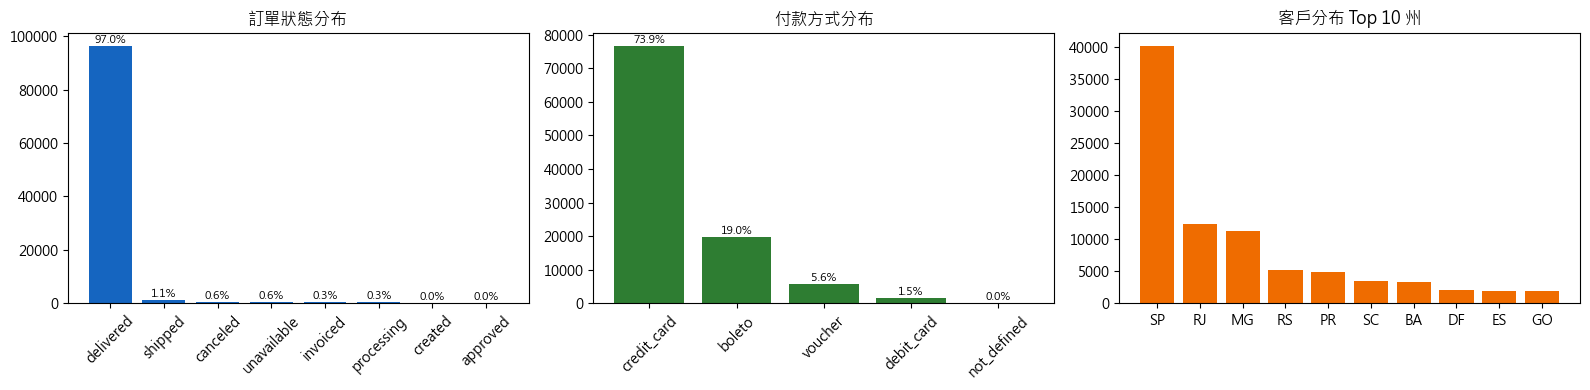

=== 訂單狀態 ===
       訂單狀態   訂單數  佔比_pct
  delivered 96478    97.0
    shipped  1107     1.1
   canceled   625     0.6
unavailable   609     0.6
   invoiced   314     0.3
 processing   301     0.3
    created     5     0.0
   approved     2     0.0

=== 付款方式 ===
       付款方式    筆數  佔比_pct  平均分期數
credit_card 76795    73.9    3.5
     boleto 19784    19.0    1.0
    voucher  5775     5.6    1.0
 debit_card  1529     1.5    1.0
not_defined     3     0.0    1.0

=== 客戶 Top 10 州 ===
 州   客戶數
SP 40302
RJ 12384
MG 11259
RS  5277
PR  4882
SC  3534
BA  3277
DF  2075
ES  1964
GO  1952


In [4]:
# 訂單狀態 / 付款方式 / 客戶州別三大分布
df_status = pd.read_sql('''
    SELECT order_status AS 訂單狀態,
           COUNT(*) AS 訂單數,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 1) AS 佔比_pct
    FROM orders
    GROUP BY order_status
    ORDER BY 訂單數 DESC
''', conn)

df_payment = pd.read_sql('''
    SELECT payment_type AS 付款方式,
           COUNT(*) AS 筆數,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM order_payments), 1) AS 佔比_pct,
           ROUND(AVG(payment_installments), 1) AS 平均分期數
    FROM order_payments
    GROUP BY payment_type
    ORDER BY 筆數 DESC
''', conn)

df_state_cust = pd.read_sql('''
    SELECT customer_state AS 州,
           COUNT(DISTINCT customer_unique_id) AS 客戶數
    FROM customers
    GROUP BY customer_state
    ORDER BY 客戶數 DESC
    LIMIT 10
''', conn)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(df_status['訂單狀態'], df_status['訂單數'], color='#1565C0')
axes[0].set_title('訂單狀態分布')
axes[0].tick_params(axis='x', rotation=45)
for i, (n, p) in enumerate(zip(df_status['訂單數'], df_status['佔比_pct'])):
    axes[0].text(i, n, f'{p}%', ha='center', va='bottom', fontsize=8)

axes[1].bar(df_payment['付款方式'], df_payment['筆數'], color='#2E7D32')
axes[1].set_title('付款方式分布')
axes[1].tick_params(axis='x', rotation=45)
for i, (n, p) in enumerate(zip(df_payment['筆數'], df_payment['佔比_pct'])):
    axes[1].text(i, n, f'{p}%', ha='center', va='bottom', fontsize=8)

axes[2].bar(df_state_cust['州'], df_state_cust['客戶數'], color='#EF6C00')
axes[2].set_title('客戶分布 Top 10 州')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

print('=== 訂單狀態 ===')
print(df_status.to_string(index=False))
print('\n=== 付款方式 ===')
print(df_payment.to_string(index=False))
print('\n=== 客戶 Top 10 州 ===')
print(df_state_cust.to_string(index=False))

**資料概況重點**

- **規模**：99,441 訂單 / 96,096 unique 客戶 / 3,095 賣家 / 71 個類目 / 27 州 / 4,119 城市，橫跨 **2016-09 ~ 2018-10**
- **訂單品質**：`delivered` 佔 **97.0%**（96,478 筆）— 後續分析皆以此狀態為主軸，排除 shipped/canceled/unavailable 等中間態（總計 ~3%）
- **付款結構**：`credit_card` 佔 **73.9%**（平均分期 **3.5 期**）、`boleto` 19.0%（巴西特有的現金繳費單）、`voucher` 5.6% — 巴西分期文化強，後續可挖「分期數高 = 高客單價？」
- **地理集中度**：SP 州佔 **41.9%** 客戶（聖保羅大都會區），東南-南五州（SP/RJ/MG/RS/PR）合計約 **77%** — 行銷與物流策略應聚焦南方
- **`customer_id` vs `customer_unique_id`**：每筆訂單都生新 `customer_id`（99,441 筆），但 `customer_unique_id` 只有 96,096 — 兩者差距 3,345 ≈ **3.4% 的回購客戶**。RFM 必須用 unique_id 才不會重複計算同一個人

## 4. 核心 KPI 與四大主視覺

四個主要分析：
- 月營收趨勢（2017–2018）
- 熱銷商品類別 Top 10
- 客戶評分分布
- 各州總營收 Top 10

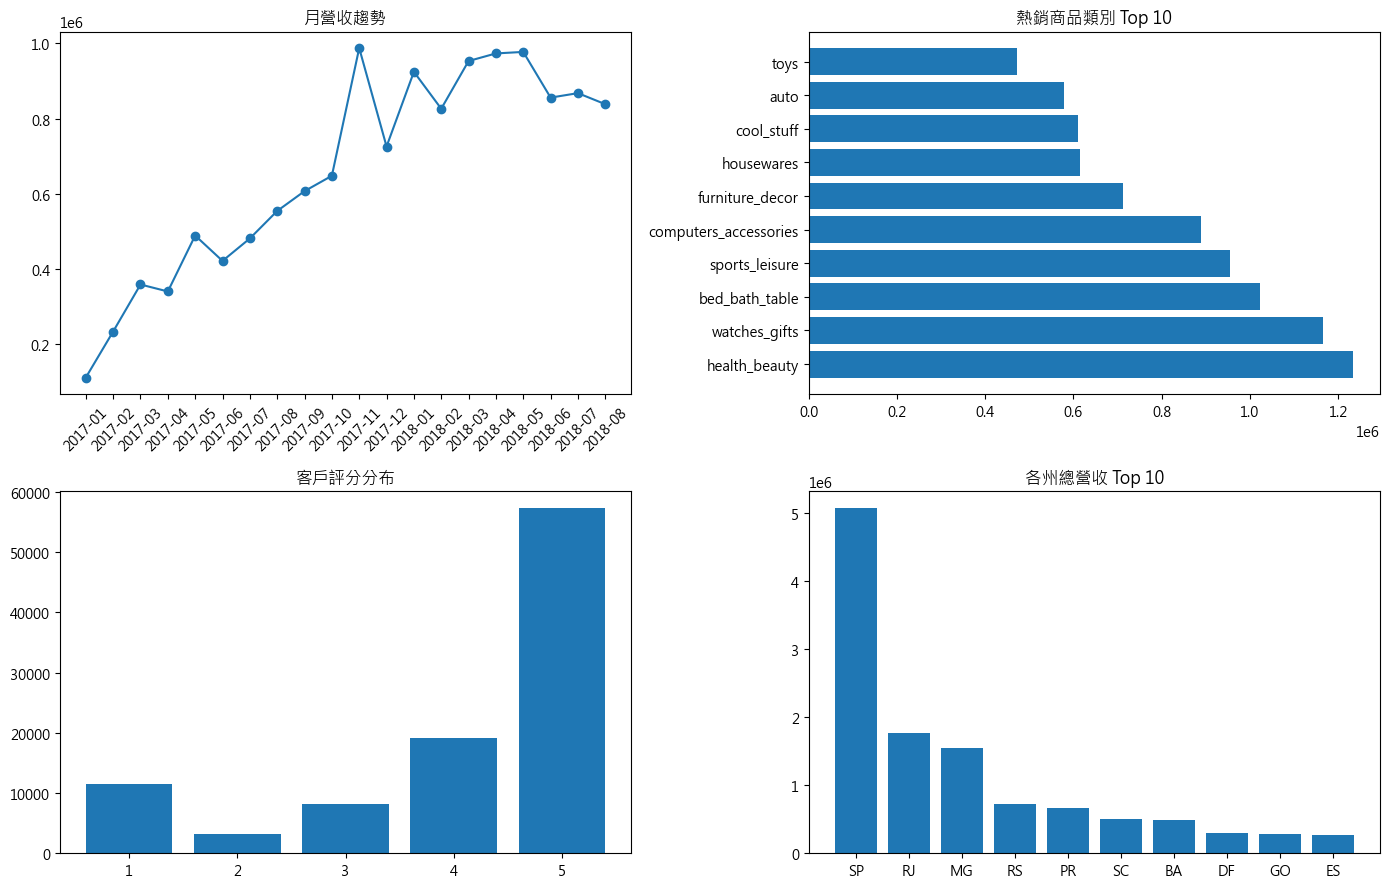

In [5]:
df_revenue = pd.read_sql('''
    SELECT strftime('%Y-%m', o.order_purchase_timestamp) AS 月份,
           ROUND(SUM(oi.price), 2) AS 總營收
    FROM orders o JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
      AND strftime('%Y-%m', o.order_purchase_timestamp) >= '2017-01'
    GROUP BY 月份 ORDER BY 月份
''', conn)

df_category = pd.read_sql('''
    SELECT ct.product_category_name_english AS 商品類別,
           ROUND(SUM(oi.price), 2) AS 總營收
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    JOIN category_translation ct ON p.product_category_name = ct.product_category_name
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY 商品類別 ORDER BY 總營收 DESC LIMIT 10
''', conn)

df_reviews = pd.read_sql('''
    SELECT review_score AS 評分, COUNT(*) AS 數量
    FROM order_reviews GROUP BY review_score ORDER BY review_score
''', conn)

df_state = pd.read_sql('''
    SELECT c.customer_state AS 州, ROUND(SUM(oi.price), 2) AS 總營收
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY 州 ORDER BY 總營收 DESC LIMIT 10
''', conn)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].plot(df_revenue['月份'], df_revenue['總營收'], marker='o')
axes[0,0].set_title('月營收趨勢'); axes[0,0].tick_params(axis='x', rotation=45)

# 2018-09 之後資料截斷，加上紅色虛線與註解避免誤讀為真實衰退
mask_cliff = df_revenue['月份'] >= '2018-09'
if mask_cliff.any():
    cliff_idx = df_revenue.index[mask_cliff][0]
    axes[0,0].axvline(x=cliff_idx - 0.5, color='red', linestyle='--', linewidth=1, alpha=0.6)
    axes[0,0].annotate('資料截斷\n（非真實衰退）',
                       xy=(cliff_idx, df_revenue.loc[cliff_idx, '總營收']),
                       xytext=(cliff_idx - 5, df_revenue['總營收'].max() * 0.55),
                       fontsize=9, color='red',
                       arrowprops=dict(arrowstyle='->', color='red', alpha=0.6))

axes[0,1].barh(df_category['商品類別'], df_category['總營收']); axes[0,1].set_title('熱銷商品類別 Top 10')
axes[1,0].bar(df_reviews['評分'], df_reviews['數量']); axes[1,0].set_title('客戶評分分布')
axes[1,1].bar(df_state['州'], df_state['總營收']); axes[1,1].set_title('各州總營收 Top 10')
plt.tight_layout(); plt.show()

**Insight**
- 月營收從 2017-01 的 ~140K 一路成長至 2017-11 的 ~1M（黑五 + 雙 11 帶動高峰）
- 2018 年趨於穩定（0.7–1.0M），顯示平台進入成熟期
- 健康美妝、watches_gifts、bed_bath_table 為三大營收支柱
- 評分集中在 5 星（佔 ~58%），但 1 星仍有 ~12%，需關注負評來源

**Recommendation**
- 行銷預算應在 Q4 前置，搭配 Top 3 品類做主推
- 1 星訂單應與物流延遲、商品描述不符做交叉分析（見下節）

## 5. 物流效率：預期 vs 實際送達天數

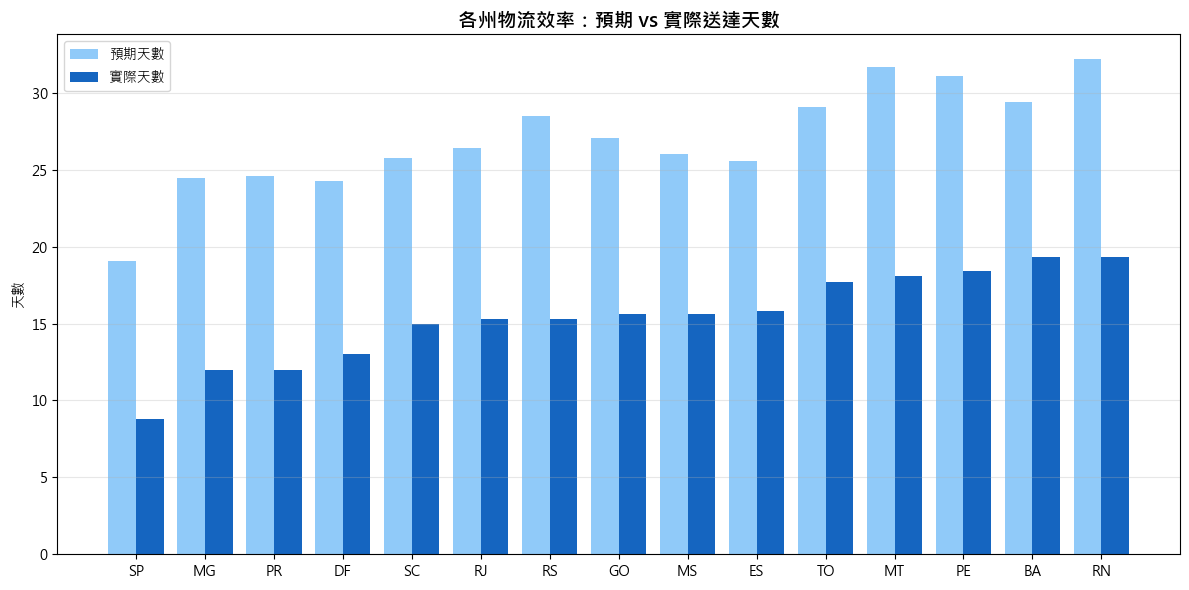

In [6]:
df_logistics = pd.read_sql('''
    SELECT
        c.customer_state AS 州,
        ROUND(AVG(JULIANDAY(o.order_delivered_customer_date) -
                  JULIANDAY(o.order_purchase_timestamp)), 1) AS 實際天數,
        ROUND(AVG(JULIANDAY(o.order_estimated_delivery_date) -
                  JULIANDAY(o.order_purchase_timestamp)), 1) AS 預期天數
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY 州
    ORDER BY 實際天數 ASC
    LIMIT 15
''', conn)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(df_logistics))
ax.bar(x, df_logistics['預期天數'], width=0.4, label='預期天數', color='#90CAF9')
ax.bar([i + 0.4 for i in x], df_logistics['實際天數'], width=0.4, label='實際天數', color='#1565C0')
ax.set_title('各州物流效率：預期 vs 實際送達天數', fontsize=14, fontweight='bold')
ax.set_xticks([i + 0.2 for i in x]); ax.set_xticklabels(df_logistics['州'])
ax.set_ylabel('天數'); ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'logistics.png'), dpi=150, bbox_inches='tight')
plt.show()

**Insight**
- 全國平均實際送達 15.4 天，比預期 ~24 天提早 ~36%（平台普遍給保守 ETA）
- SP（聖保羅）僅 8.8 天，物流最強；RN/BA 仍需 19+ 天，差距明顯
- 預期 vs 實際的 gap 在偏遠州（MT/PE/BA/RN）特別大，代表 ETA 給太寬鬆，使用者體感雖好但可能影響購買決策

**Recommendation**
- 將 SP 倉儲/配送模式逐步複製到 RJ、MG、RS 等高訂單州，可進一步壓低送達天數
- 偏遠州 ETA 過於保守 → 行銷頁可改顯示「預估 X 天送達」更積極的數字以提升轉換

## 6. 匯出 CSV 給 Tableau

In [7]:
for name, df in [
    ('revenue', df_revenue),
    ('category', df_category),
    ('reviews', df_reviews),
    ('state', df_state),
    ('logistics', df_logistics),
]:
    df.to_csv(os.path.join(OUTPUT_DIR, f'{name}.csv'), index=False)
print('CSV 匯出完成')

CSV 匯出完成


## 7. 整體 KPI 與年度成長

In [8]:
kpi = pd.read_sql('''
    SELECT
        ROUND(SUM(oi.price)/1000000, 2) AS 總營收_M,
        COUNT(DISTINCT o.order_id)      AS 總訂單數,
        ROUND(AVG(r.review_score), 1)   AS 平均評分,
        ROUND(AVG(JULIANDAY(o.order_delivered_customer_date) -
                  JULIANDAY(o.order_purchase_timestamp)), 1) AS 平均送達天數
    FROM orders o
    JOIN order_items oi   ON o.order_id = oi.order_id
    JOIN order_reviews r  ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
''', conn)
kpi

,總營收_M,總訂單數,平均評分,平均送達天數
0,13.17,95824,4.1,12.4


In [9]:
kpi_yearly = pd.read_sql('''
    SELECT
        strftime('%Y', o.order_purchase_timestamp) AS 年份,
        ROUND(SUM(oi.price)/1000000, 2) AS 總營收_M,
        COUNT(DISTINCT o.order_id)      AS 總訂單數,
        ROUND(AVG(r.review_score), 1)   AS 平均評分,
        ROUND(AVG(JULIANDAY(o.order_delivered_customer_date) -
                  JULIANDAY(o.order_purchase_timestamp)), 1) AS 平均送達天數
    FROM orders o
    JOIN order_items oi   ON o.order_id = oi.order_id
    JOIN order_reviews r  ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY 年份
''', conn)
kpi_yearly.to_csv(os.path.join(OUTPUT_DIR, 'kpi_yearly.csv'), index=False)
kpi_yearly

,年份,總營收_M,總訂單數,平均評分,平均送達天數
0,2016,0.04,264,3.9,19.6
1,2017,5.94,43098,4.1,12.9
2,2018,7.19,52462,4.1,12.0


## 8. RFM 客戶分群分析

**為什麼做 RFM？**
營收與訂單只看到「公司賺多少」，看不到「客戶結構」。RFM 是電商分群最常用的方法：
- **R (Recency)**：距最後一次購買天數
- **F (Frequency)**：購買次數
- **M (Monetary)**：累積消費金額

以最後一筆訂單日期為觀察點，用 NTILE(5) 對每個維度打 1–5 分，再以分數組合分群。

In [10]:
rfm = pd.read_sql('''
    WITH snapshot AS (
        SELECT MAX(order_purchase_timestamp) AS snapshot_date
        FROM orders WHERE order_status = 'delivered'
    ),
    rfm_base AS (
        SELECT
            c.customer_unique_id,
            ROUND(JULIANDAY((SELECT snapshot_date FROM snapshot)) -
                  JULIANDAY(MAX(o.order_purchase_timestamp)), 0) AS recency_days,
            COUNT(DISTINCT o.order_id) AS frequency,
            ROUND(SUM(oi.price), 2)    AS monetary
        FROM orders o
        JOIN order_items oi ON o.order_id = oi.order_id
        JOIN customers c    ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id
    )
    SELECT
        customer_unique_id,
        recency_days,
        frequency,
        monetary,
        NTILE(5) OVER (ORDER BY recency_days DESC) AS r_score,
        NTILE(5) OVER (ORDER BY frequency ASC)     AS f_score,
        NTILE(5) OVER (ORDER BY monetary ASC)      AS m_score
    FROM rfm_base
''', conn)

def segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 4 and f >= 4 and m >= 4: return '冠軍客戶'
    if r >= 4 and f >= 3:            return '忠誠客戶'
    if r >= 4:                       return '潛力新客'
    if r <= 2 and f >= 3:            return '流失風險'
    if r <= 2:                       return '已流失'
    return '一般客戶'

rfm['segment'] = rfm.apply(segment, axis=1)
rfm.head()

,customer_unique_id,recency_days,frequency,monetary,r_score,f_score,m_score,segment
0,830d5b7aaa3b6f1e9ad63703bec97d23,713.0,1,134.97,1,4,4,流失風險
1,2f64e403852e6893ae37485d5fcacdaf,695.0,1,21.90,1,1,1,已流失
2,87776adb449c551e74c13fc34f036105,695.0,1,29.99,1,1,1,已流失
3,61db744d2f835035a5625b59350c6b63,695.0,1,36.49,1,1,1,已流失
4,10e89fd8e5c745f81bec101207ba4d7d,695.0,1,74.90,1,3,3,流失風險


In [11]:
segment_summary = (
    rfm.groupby('segment')
       .agg(客戶數=('customer_unique_id', 'count'),
            平均_R_天=('recency_days', 'mean'),
            平均_F_次=('frequency', 'mean'),
            平均_M_元=('monetary', 'mean'),
            群組總營收=('monetary', 'sum'))
       .round(1)
       .sort_values('群組總營收', ascending=False)
)
segment_summary['營收佔比_%'] = (
    segment_summary['群組總營收'] / segment_summary['群組總營收'].sum() * 100
).round(1)
segment_summary['客戶佔比_%'] = (
    segment_summary['客戶數'] / segment_summary['客戶數'].sum() * 100
).round(1)
segment_summary

,客戶數,平均_R_天,平均_F_次,平均_M_元,群組總營收,營收佔比_%,客戶佔比_%
segment,,,,,,,
流失風險,21975,393.2,1.0,213.4,4688537.4,35.5,23.5
冠軍客戶,15151,90.9,1.1,274.3,4155457.5,31.4,16.2
一般客戶,18672,219.4,1.0,134.3,2507492.9,19.0,20.0
忠誠客戶,7612,90.1,1.0,88.8,675660.2,5.1,8.2
已流失,15369,395.5,1.0,40.2,617836.7,4.7,16.5
潛力新客,14579,88.8,1.0,39.5,576513.3,4.4,15.6


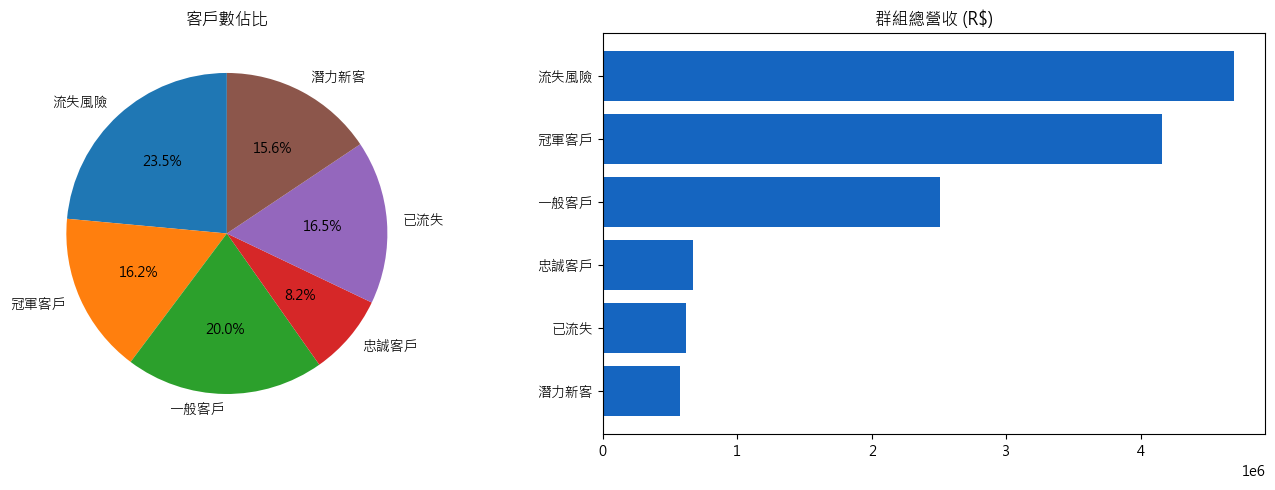

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(segment_summary['客戶數'], labels=segment_summary.index,
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('客戶數佔比')

axes[1].barh(segment_summary.index, segment_summary['群組總營收'], color='#1565C0')
axes[1].set_title('群組總營收 (R$)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rfm_segments.png'), dpi=150, bbox_inches='tight')
plt.show()

segment_summary.to_csv(os.path.join(OUTPUT_DIR, 'rfm_segments.csv'))

**Insight**
- Olist 客戶以「一次性購買」為主，**冠軍/忠誠客戶佔比偏低**，平均 F 多落在 1 次
- 「已流失」群組佔客戶數比例最高（R > 中位數），代表平台**回購機制薄弱**
- 「流失風險」群組雖然人數少，但平均 M 較高，是優先挽回的對象

**Recommendation**

| 分群 | 行銷策略 |
|---|---|
| 冠軍客戶 | VIP 制度、新品優先試用、推薦獎勵 |
| 忠誠客戶 | 訂閱制、回購折扣 |
| 潛力新客 | 第二次購買誘因（首購回饋、48 小時限時券） |
| 流失風險 | 個人化召回 EDM、限時免運 |
| 已流失 | 大額折扣喚回 + 滿意度問卷找原因 |
| 一般客戶 | 商品推薦、加購建議提高 AOV |

## 9. 總結

| 主題 | 關鍵發現 | 行動建議 |
|---|---|---|
| 營收 | 2017 Q4 為高峰，2018 進入穩定期 | Q4 前置行銷預算、強化 Top 3 品類 |
| 品類 | 健康美妝、手錶禮品、寢具家飾為三大支柱 | 主推品類加碼、長尾品類淘汰 |
| 評分 | 5 星 ~58%，但 1 星仍有 ~12% | 1 星訂單交叉分析物流延遲與商品描述 |
| 物流 | SP 8.8 天，RN 19.3 天，差距明顯 | 複製 SP 倉配模式、偏遠州 ETA 改為更積極數字 |
| 客戶 | 一次性購買為主，回購薄弱 | 第二次購買誘因 + 流失風險挽回方案 |

## 後續可延伸
- Cohort 分析：每月新客的 N 個月後留存率
- 商品評分與物流天數的相關性檢定
- 月營收時間序列預測（Prophet / ARIMA）